<a href="https://colab.research.google.com/github/prithwis/FDS/blob/main/EDA_eCommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![alt text](https://github.com/Praxis-QR/RDWH/raw/main/images/YantraJaalBanner.png)<br>


<hr>

[Prithwis Mukerjee](http://www.linkedin.com/in/prithwis)<br>

#Exploratory Data Analysis <br>
[Admond Lee article](https://towardsdatascience.com/exploratory-data-analysis-on-e-commerce-data-be24c72b32b2) <br>
[full data set](https://www.kaggle.com/carrie1/ecommerce-data)

#Setup, Imports

In [1]:
#!pip -q install pandas-profiling
#!pip -q install typing-extensions --upgrade

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
# current version of seaborn generates a bunch of warnings that we'll ignore
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

#import missingno as msno # missing data visualization module for Python
#import pandas_profiling

import gc
import datetime

%matplotlib inline
color = sns.color_palette()

In [3]:
pd.set_option('display.max_rows', 10000)
pd.set_option('display.max_columns', 100)

#Fetch Data

In [4]:
# Original Data https://www.kaggle.com/carrie1/ecommerce-data
# Same data in Google Drive https://drive.google.com/open?id=1K_rQftggePnII3K6613MumhKo3dTMO5r
# 10% data in Google Drive https://drive.google.com/file/d/1YjCMPc4vUuXvWik1u4p5aP-THJUJjvDX/view?usp=sharing
!wget -q -O eCommerce.csv 'https://drive.google.com/uc?export=download&id=1K_rQftggePnII3K6613MumhKo3dTMO5r'       # full data
#!wget -O eCommerce02.csv 'https://drive.google.com/uc?export=download&id=1YjCMPc4vUuXvWik1u4p5aP-THJUJjvDX'      # 10% data

In [5]:
# specify encoding to deal with different formats
df = pd.read_csv('eCommerce.csv', encoding = 'ISO-8859-1')
#df = pd.read_csv('eCommerce02.csv', encoding = 'ISO-8859-1')
#df = pd.read_csv('eCommerce.csv')

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.count()

,0
InvoiceNo,541909
StockCode,541909
Description,540455
Quantity,541909
InvoiceDate,541909
UnitPrice,541909
CustomerID,406829
Country,541909


In [8]:
# change the column names
df.rename(index=str, columns={'InvoiceNo': 'invoice_num',
                              'StockCode' : 'stock_code',
                              'Description' : 'description',
                              'Quantity' : 'quantity',
                              'InvoiceDate' : 'invoice_date',
                              'UnitPrice' : 'unit_price',
                              'CustomerID' : 'cust_id',
                              'Country' : 'country'}, inplace=True)

In [9]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#Data Cleaning

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_num   541909 non-null  object 
 1   stock_code    541909 non-null  object 
 2   description   540455 non-null  object 
 3   quantity      541909 non-null  int64  
 4   invoice_date  541909 non-null  object 
 5   unit_price    541909 non-null  float64
 6   cust_id       406829 non-null  float64
 7   country       541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 37.2+ MB


In [11]:
# check missing values for each column
df.isnull().sum().sort_values(ascending=False)

,0
cust_id,135080
description,1454
stock_code,0
invoice_num,0
quantity,0
invoice_date,0
unit_price,0
country,0


In [12]:
# check out the rows with missing values
df[df.isnull().any(axis=1)].head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [13]:
# change the invoice_date format - String to Timestamp format
df['invoice_date'] = pd.to_datetime(df.invoice_date, format='%m/%d/%Y %H:%M')

In [14]:
# change description - UPPER case to LOWER case
df['description'] = df.description.str.lower()

In [15]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
df.isnull().sum().sort_values(ascending=False)

,0
cust_id,135080
description,1454
stock_code,0
invoice_num,0
quantity,0
invoice_date,0
unit_price,0
country,0


In [17]:
# df_new without missing values
df2 = df.dropna()

In [18]:
# check missing values for each column
df2.isnull().sum().sort_values(ascending=False)

,0
invoice_num,0
stock_code,0
description,0
quantity,0
invoice_date,0
unit_price,0
cust_id,0
country,0


In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_num   406829 non-null  object        
 1   stock_code    406829 non-null  object        
 2   description   406829 non-null  object        
 3   quantity      406829 non-null  int64         
 4   invoice_date  406829 non-null  datetime64[ns]
 5   unit_price    406829 non-null  float64       
 6   cust_id       406829 non-null  float64       
 7   country       406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [20]:
# change columns tyoe - String to Int type
df2['cust_id'] = df2['cust_id'].astype('int64')

In [21]:
df2.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_num   406829 non-null  object        
 1   stock_code    406829 non-null  object        
 2   description   406829 non-null  object        
 3   quantity      406829 non-null  int64         
 4   invoice_date  406829 non-null  datetime64[ns]
 5   unit_price    406829 non-null  float64       
 6   cust_id       406829 non-null  int64         
 7   country       406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.9+ MB


In [23]:
df2.describe().round(2)

,quantity,invoice_date,unit_price,cust_id
count,406829.00,406829,406829.00,406829.00
mean,12.06,2011-07-10 16:30:57.879207424,3.46,15287.69
min,-80995.00,2010-12-01 08:26:00,0.00,12346.00
25%,2.00,2011-04-06 15:02:00,1.25,13953.00
50%,5.00,2011-07-31 11:48:00,1.95,15152.00
75%,12.00,2011-10-20 13:06:00,3.75,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,248.69,NaN,69.32,1713.60


In [24]:
df2 = df2[df2.quantity > 0]

In [25]:
df2.describe().round(2)

,quantity,invoice_date,unit_price,cust_id
count,397924.00,397924,397924.00,397924.00
mean,13.02,2011-07-10 23:43:36.912475648,3.12,15294.32
min,1.00,2010-12-01 08:26:00,0.00,12346.00
25%,2.00,2011-04-07 11:12:00,1.25,13969.00
50%,6.00,2011-07-31 14:39:00,1.95,15159.00
75%,12.00,2011-10-20 14:33:00,3.75,16795.00
max,80995.00,2011-12-09 12:50:00,8142.75,18287.00
std,180.42,NaN,22.10,1713.17


In [26]:
# add new column
df2['amount_spent'] = df2['quantity'] * df2['unit_price']

In [27]:
# rearrange all the columns for easy reference
df2 = df2[['invoice_num','invoice_date','stock_code','description','quantity','unit_price','amount_spent','cust_id','country']]

In [28]:
# Add Month Day Hour
df2.insert(loc=2, column='year_month', value=df2['invoice_date'].map(lambda x: 100*x.year + x.month))
df2.insert(loc=3, column='month', value=df2.invoice_date.dt.month)
# +1 to make Monday=1.....until Sunday=7
df2.insert(loc=4, column='day', value=(df2.invoice_date.dt.dayofweek)+1)
df2.insert(loc=5, column='hour', value=df2.invoice_date.dt.hour)

In [29]:
df2.head()

,invoice_num,invoice_date,year_month,month,day,hour,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,12,3,8,85123A,white hanging heart t-light holder,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,12,3,8,71053,white metal lantern,6,3.39,20.34,17850,United Kingdom
2,536365,2010-12-01 08:26:00,201012,12,3,8,84406B,cream cupid hearts coat hanger,8,2.75,22.00,17850,United Kingdom
3,536365,2010-12-01 08:26:00,201012,12,3,8,84029G,knitted union flag hot water bottle,6,3.39,20.34,17850,United Kingdom
4,536365,2010-12-01 08:26:00,201012,12,3,8,84029E,red woolly hottie white heart.,6,3.39,20.34,17850,United Kingdom


#Exploratory Data Analysis

In [30]:
df2.groupby(by=['cust_id','country'], as_index=False)['invoice_num'].count().head()

,cust_id,country,invoice_num
0,12346,United Kingdom,1
1,12347,Iceland,182
2,12348,Finland,31
3,12349,Italy,73
4,12350,Norway,17


In [31]:
orders = df2.groupby(by=['cust_id','country'], as_index=False)['invoice_num'].count()

In [32]:
orders.head()

,cust_id,country,invoice_num
0,12346,United Kingdom,1
1,12347,Iceland,182
2,12348,Finland,31
3,12349,Italy,73
4,12350,Norway,17


<Axes: xlabel='cust_id'>

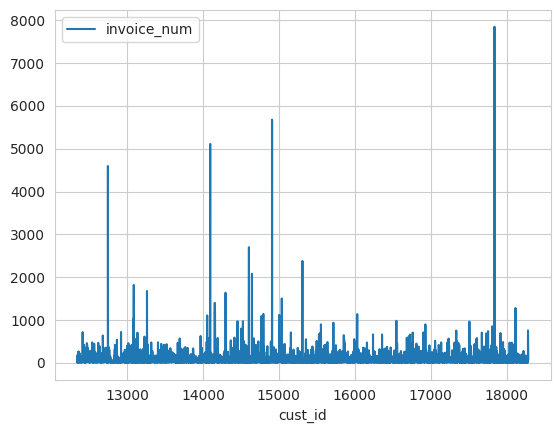

In [33]:
orders.plot(
    x='cust_id',
    y=['invoice_num'],
    legend=True
)

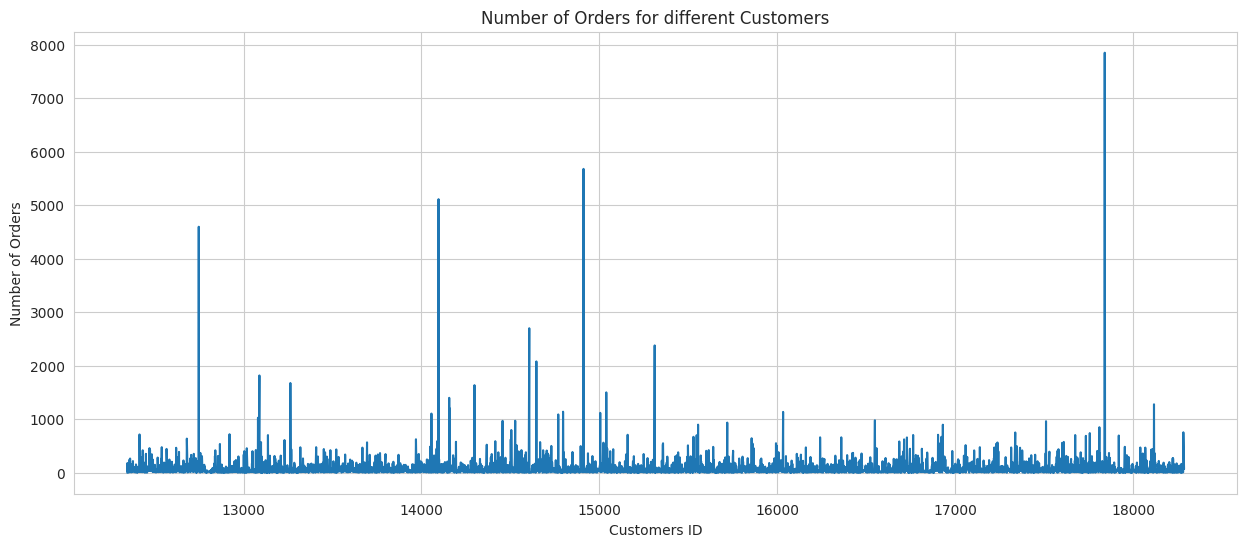

In [34]:
plt.subplots(figsize=(15,6))
plt.plot(orders.cust_id, orders.invoice_num)
plt.xlabel('Customers ID')
plt.ylabel('Number of Orders')
plt.title('Number of Orders for different Customers')
plt.show()

In [35]:
print('The TOP 5 customers with most number of orders...')
orders.sort_values(by='invoice_num', ascending=False).head()

The TOP 5 customers with most number of orders...


,cust_id,country,invoice_num
4019,17841,United Kingdom,7847
1888,14911,EIRE,5677
1298,14096,United Kingdom,5111
334,12748,United Kingdom,4596
1670,14606,United Kingdom,2700


In [36]:
money_spent = df2.groupby(by=['cust_id','country'], as_index=False)['amount_spent'].sum()

#plt.subplots(figsize=(15,6))
#plt.plot(money_spent.cust_id, money_spent.amount_spent)
#plt.xlabel('Customers ID')
#plt.ylabel('Money spent (Dollar)')
#plt.title('Money Spent for different Customers')
#plt.show()

money_spent.head()

,cust_id,country,amount_spent
0,12346,United Kingdom,77183.60
1,12347,Iceland,4310.00
2,12348,Finland,1797.24
3,12349,Italy,1757.55
4,12350,Norway,334.40


<Axes: xlabel='cust_id'>

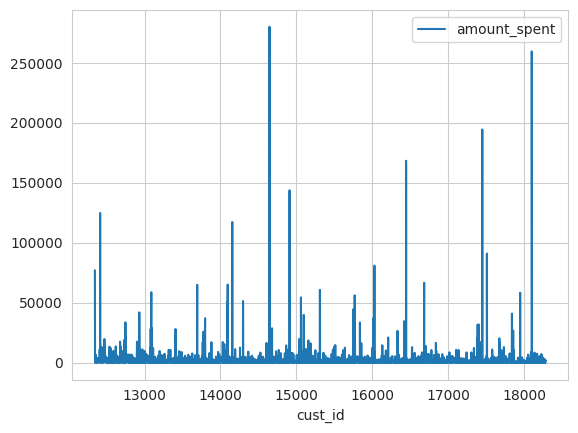

In [37]:
money_spent.plot(
    x='cust_id',
    y=['amount_spent'],
    legend=True
)

In [38]:
print('The TOP 5 customers with highest money spent...')
money_spent.sort_values(by='amount_spent', ascending=False).head()

The TOP 5 customers with highest money spent...


,cust_id,country,amount_spent
1698,14646,Netherlands,280206.02
4210,18102,United Kingdom,259657.30
3737,17450,United Kingdom,194550.79
3017,16446,United Kingdom,168472.50
1888,14911,EIRE,143825.06


#Patterns

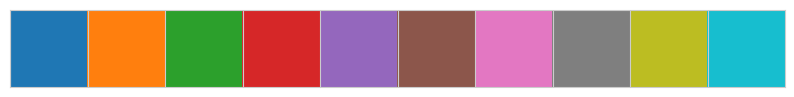

In [39]:
# color available
sns.palplot(color)

In [40]:
df2.head()

,invoice_num,invoice_date,year_month,month,day,hour,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,12,3,8,85123A,white hanging heart t-light holder,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,12,3,8,71053,white metal lantern,6,3.39,20.34,17850,United Kingdom
2,536365,2010-12-01 08:26:00,201012,12,3,8,84406B,cream cupid hearts coat hanger,8,2.75,22.00,17850,United Kingdom
3,536365,2010-12-01 08:26:00,201012,12,3,8,84029G,knitted union flag hot water bottle,6,3.39,20.34,17850,United Kingdom
4,536365,2010-12-01 08:26:00,201012,12,3,8,84029E,red woolly hottie white heart.,6,3.39,20.34,17850,United Kingdom


In [41]:
#df2.groupby('year_month')['invoice_num','cust_id'].count()
df2.groupby('year_month')['invoice_num'].count().sort_index()

,invoice_num
year_month,
201012,26160
201101,21232
201102,19928
201103,27177
201104,22644
201105,28322
201106,27185
201107,26827
201108,27013


<Axes: xlabel='year_month'>

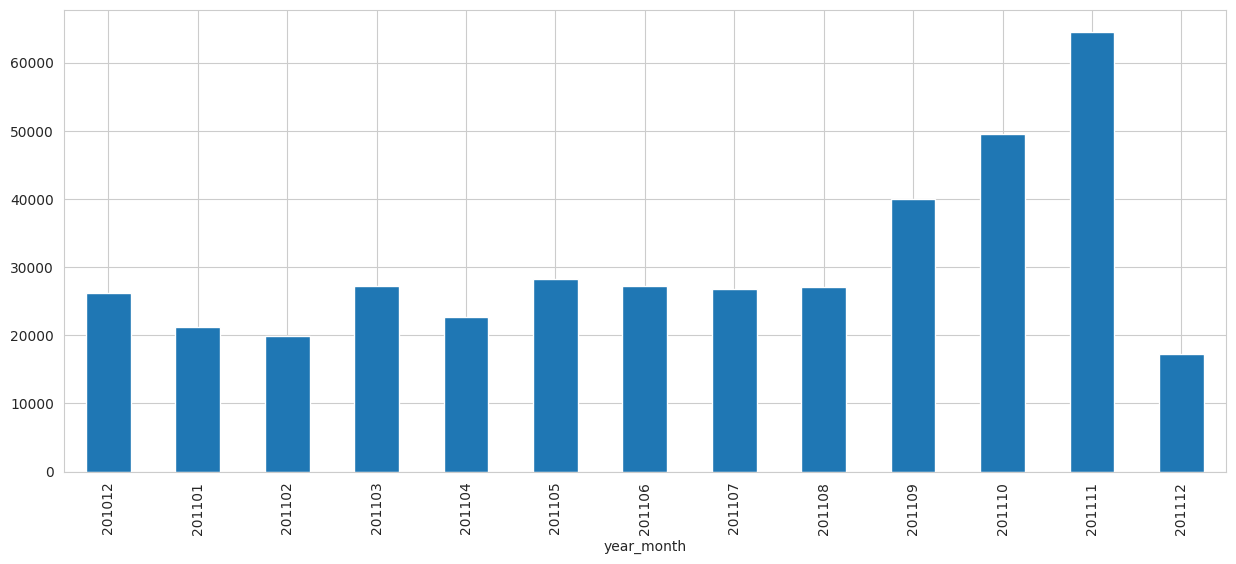

In [42]:
df2.groupby('year_month')['invoice_num'].count().sort_index().plot(kind='bar',color=color[0],figsize=(15,6))

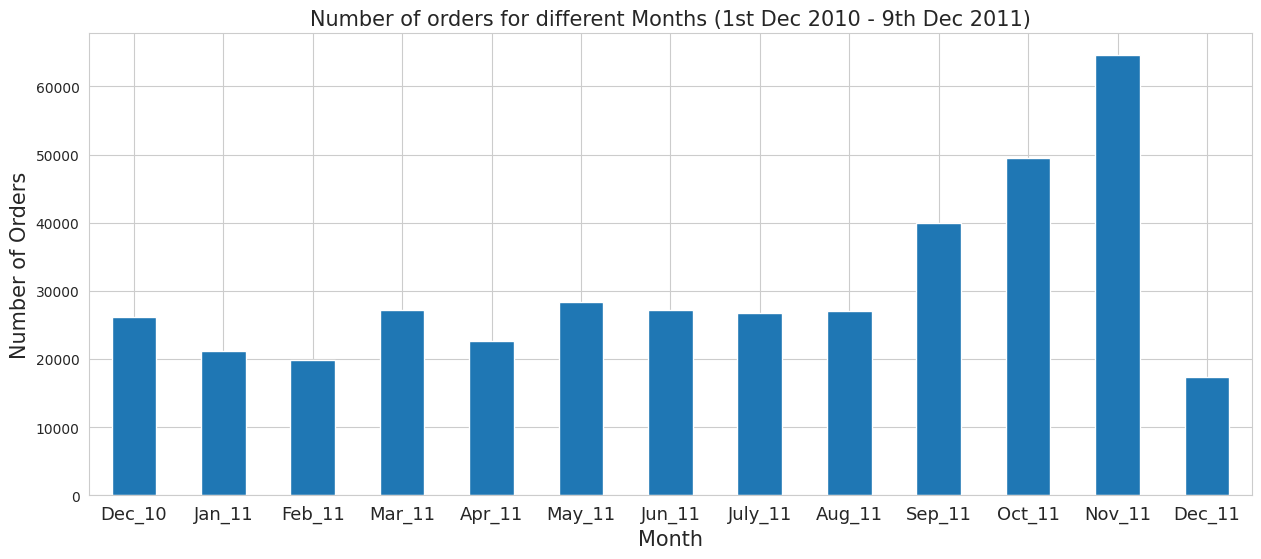

In [43]:
#Orders per month
#ax = df2.groupby('invoice_num')['year_month'].unique().value_counts().sort_index().plot(kind='bar',color=color[0],figsize=(15,6))
ax = df2.groupby('year_month')['invoice_num'].count().sort_index().plot(kind='bar',color=color[0],figsize=(15,6))
ax.set_xlabel('Month',fontsize=15)
ax.set_ylabel('Number of Orders',fontsize=15)
ax.set_title('Number of orders for different Months (1st Dec 2010 - 9th Dec 2011)',fontsize=15)
ax.set_xticklabels(('Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11'), rotation='horizontal', fontsize=13)
plt.show()

In [44]:
#Orders by Day
#df2.groupby('invoice_num')['day'].unique().value_counts().sort_index()
df2.groupby('day')['invoice_num'].count().sort_index()

,invoice_num
day,
1,64899
2,66476
3,68888
4,80052
5,54834
7,62775


<Axes: xlabel='day'>

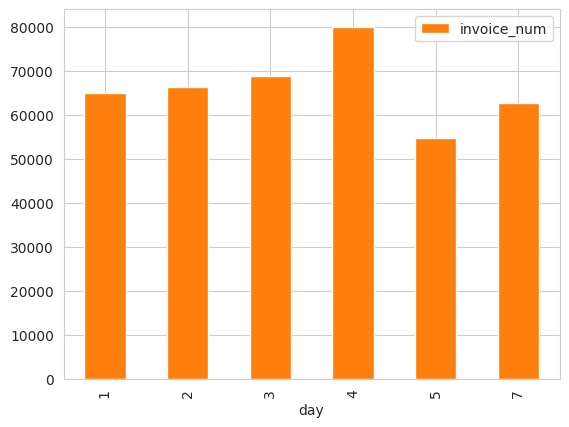

In [45]:
df2.groupby('day')['invoice_num'].count().sort_index().plot(
    kind='bar',
    color=color[1],
    legend=True
)

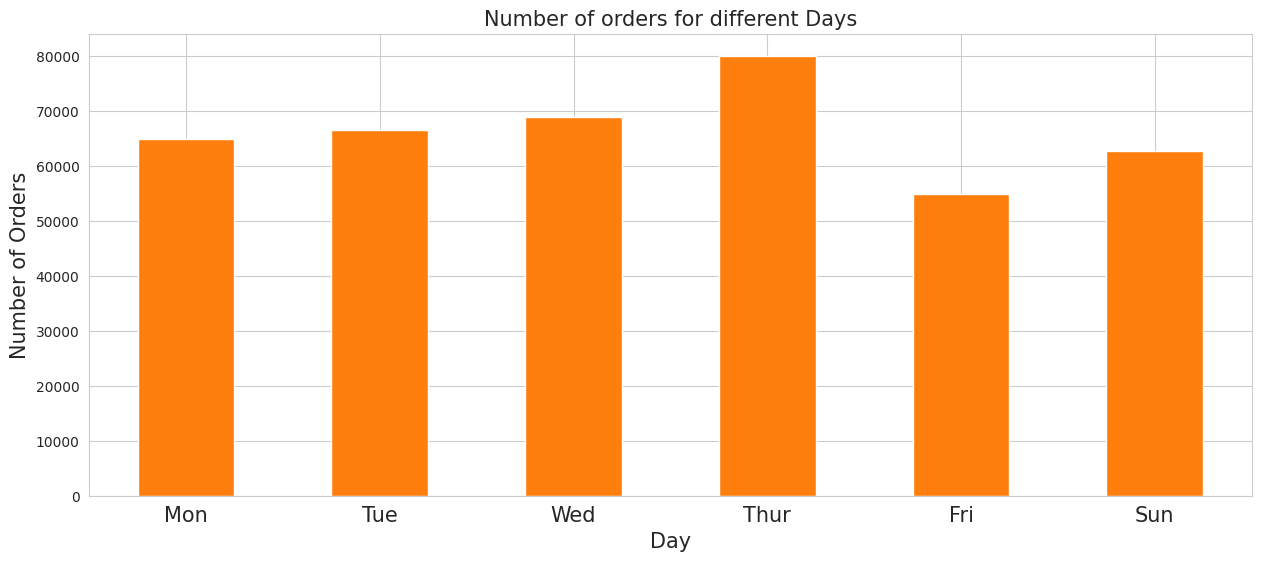

In [46]:
#ax = df2.groupby('invoice_num')['day'].unique().value_counts().sort_index().plot(kind='bar',color=color[1],figsize=(15,6))
ax = df2.groupby('day')['invoice_num'].count().sort_index().plot(kind='bar',color=color[1],figsize=(15,6))
ax.set_xlabel('Day',fontsize=15)
ax.set_ylabel('Number of Orders',fontsize=15)
ax.set_title('Number of orders for different Days',fontsize=15)
ax.set_xticklabels(('Mon','Tue','Wed','Thur','Fri','Sun'), rotation='horizontal', fontsize=15)
plt.show()

In [47]:
#Orders per hour
df2[['invoice_num','hour']].groupby('hour').count().sort_index()

,invoice_num
hour,
6,1
7,379
8,8691
9,21945
10,37999
11,49092
12,72069
13,64031
14,54127


In [48]:
#Orders per hour
#df2.groupby('invoice_num')['hour'].unique().value_counts().iloc[:-1].sort_index()
df2.groupby('hour')['hour'].unique().value_counts().iloc[:-1].sort_index()

,count
hour,
[6],1
[7],1
[8],1
[9],1
[10],1
[11],1
[12],1
[13],1
[14],1


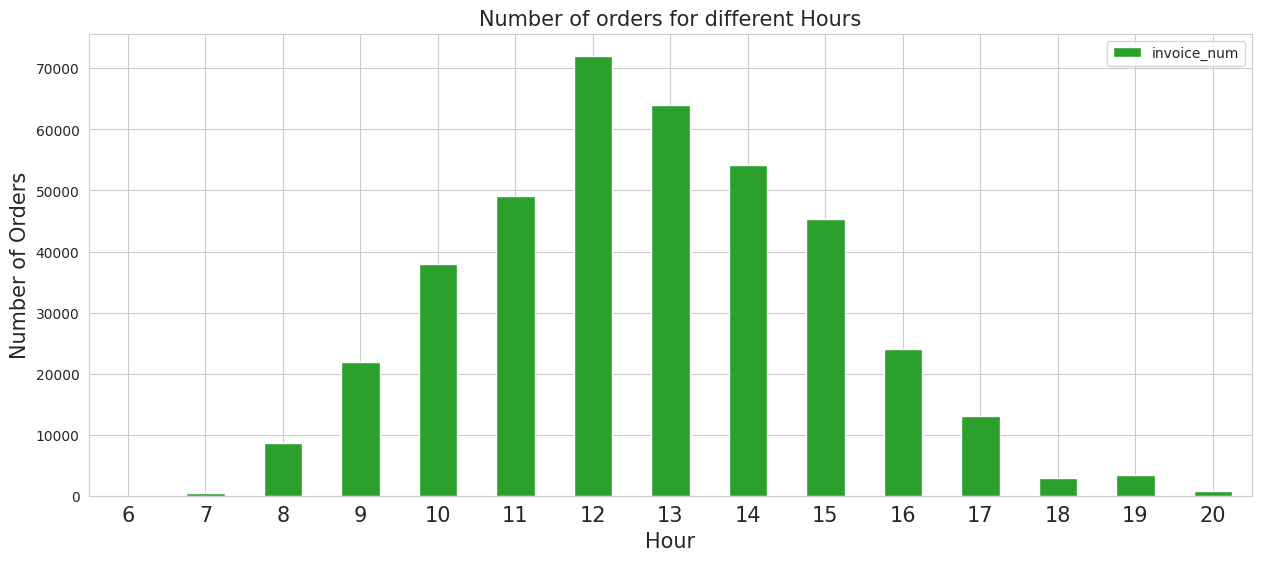

In [49]:
ax = df2[['invoice_num','hour']].groupby('hour').count().sort_index().plot(kind='bar',color=color[2],figsize=(15,6))
ax.set_xlabel('Hour',fontsize=15)
ax.set_ylabel('Number of Orders',fontsize=15)
ax.set_title('Number of orders for different Hours',fontsize=15)
ax.set_xticklabels(range(6,21), rotation='horizontal', fontsize=15)
plt.show()

In [50]:
# Unit price
df2.unit_price.describe()

,unit_price
count,397924.000000
mean,3.116174
std,22.096788
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,8142.750000


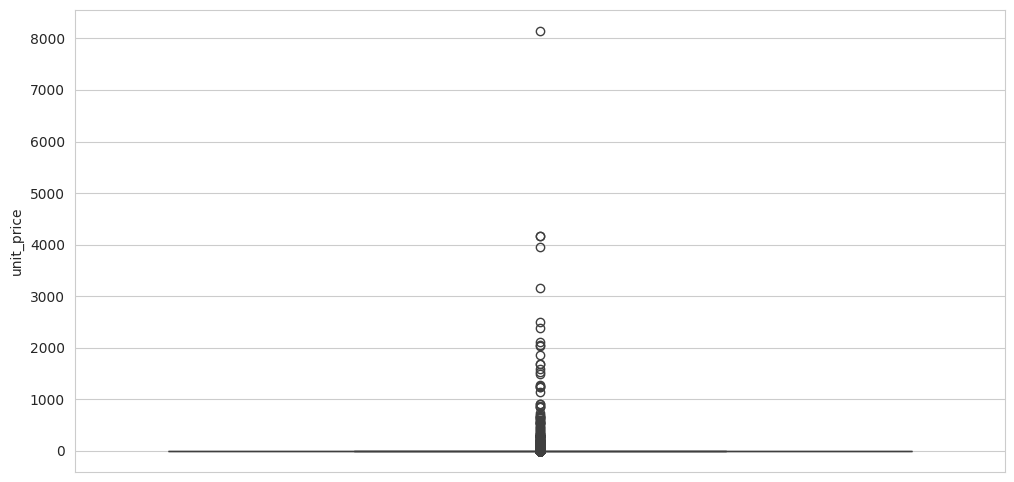

In [51]:
# check the distribution of unit price
plt.subplots(figsize=(12,6))
sns.boxplot(df2.unit_price)
plt.show()

In [52]:
df_free = df2[df2.unit_price == 0]
df_free.head()

,invoice_num,invoice_date,year_month,month,day,hour,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
9302,537197,2010-12-05 14:02:00,201012,12,7,14,22841,round cake tin vintage green,1,0.0,0.0,12647,Germany
33576,539263,2010-12-16 14:36:00,201012,12,4,14,22580,advent calendar gingham sack,4,0.0,0.0,16560,United Kingdom
40089,539722,2010-12-21 13:45:00,201012,12,2,13,22423,regency cakestand 3 tier,10,0.0,0.0,14911,EIRE
47068,540372,2011-01-06 16:41:00,201101,1,4,16,22090,paper bunting retrospot,24,0.0,0.0,13081,United Kingdom
47070,540372,2011-01-06 16:41:00,201101,1,4,16,22553,plasters in tin skulls,24,0.0,0.0,13081,United Kingdom


In [53]:
df_free.year_month.value_counts().sort_index()

,count
year_month,
201012,3
201101,3
201102,1
201103,2
201104,2
201105,2
201107,2
201108,6
201109,2


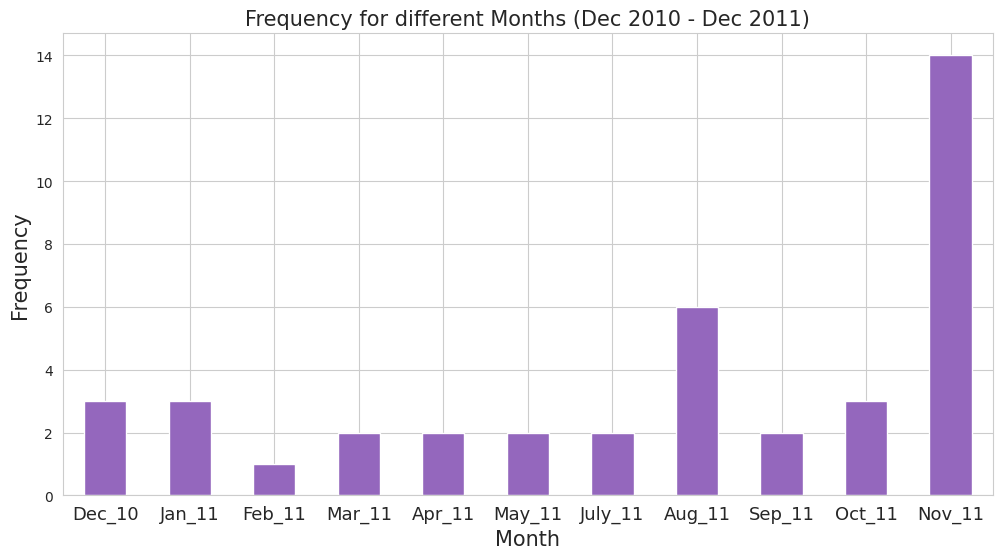

In [54]:
ax = df_free.year_month.value_counts().sort_index().plot(kind='bar',figsize=(12,6), color=color[4])
ax.set_xlabel('Month',fontsize=15)
ax.set_ylabel('Frequency',fontsize=15)
ax.set_title('Frequency for different Months (Dec 2010 - Dec 2011)',fontsize=15)
ax.set_xticklabels(('Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11'), rotation='horizontal', fontsize=13)
plt.show()

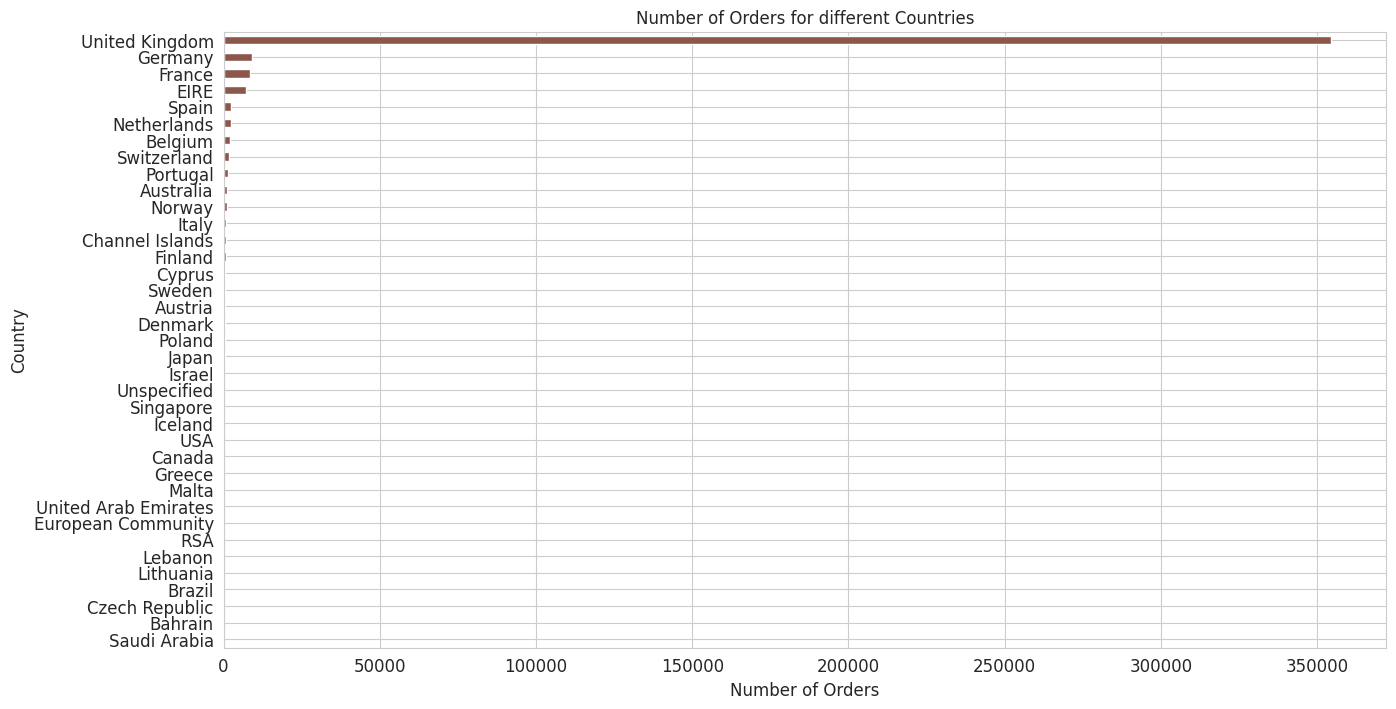

In [55]:
# By Country
group_country_orders = df2.groupby('country')['invoice_num'].count().sort_values()
# del group_country_orders['United Kingdom']

# plot number of unique customers in each country (with UK)
plt.subplots(figsize=(15,8))
group_country_orders.plot(kind='barh', fontsize=12, color=color[5])
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Number of Orders for different Countries', fontsize=12)
plt.show()

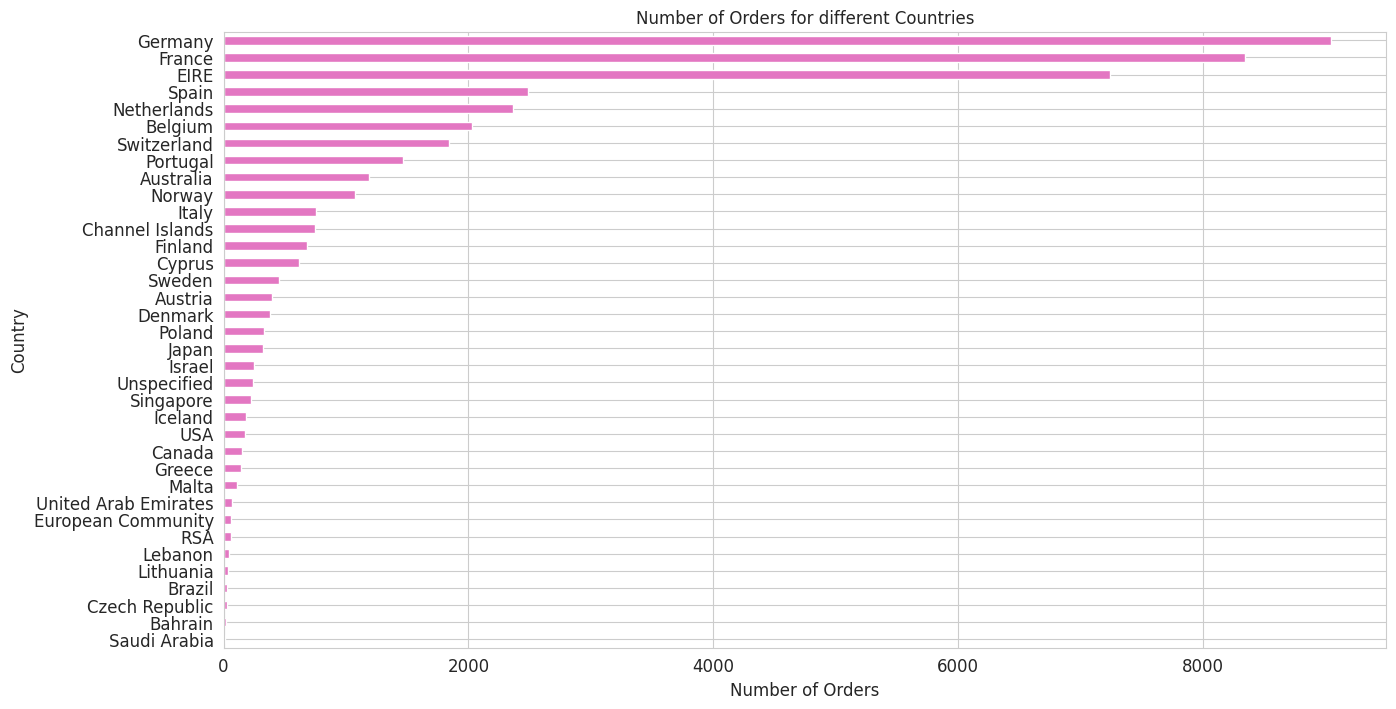

In [56]:
group_country_orders = df2.groupby('country')['invoice_num'].count().sort_values()
del group_country_orders['United Kingdom']

# plot number of unique customers in each country (without UK)
plt.subplots(figsize=(15,8))
group_country_orders.plot(kind='barh', fontsize=12, color=color[6])
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Number of Orders for different Countries', fontsize=12)
plt.show()

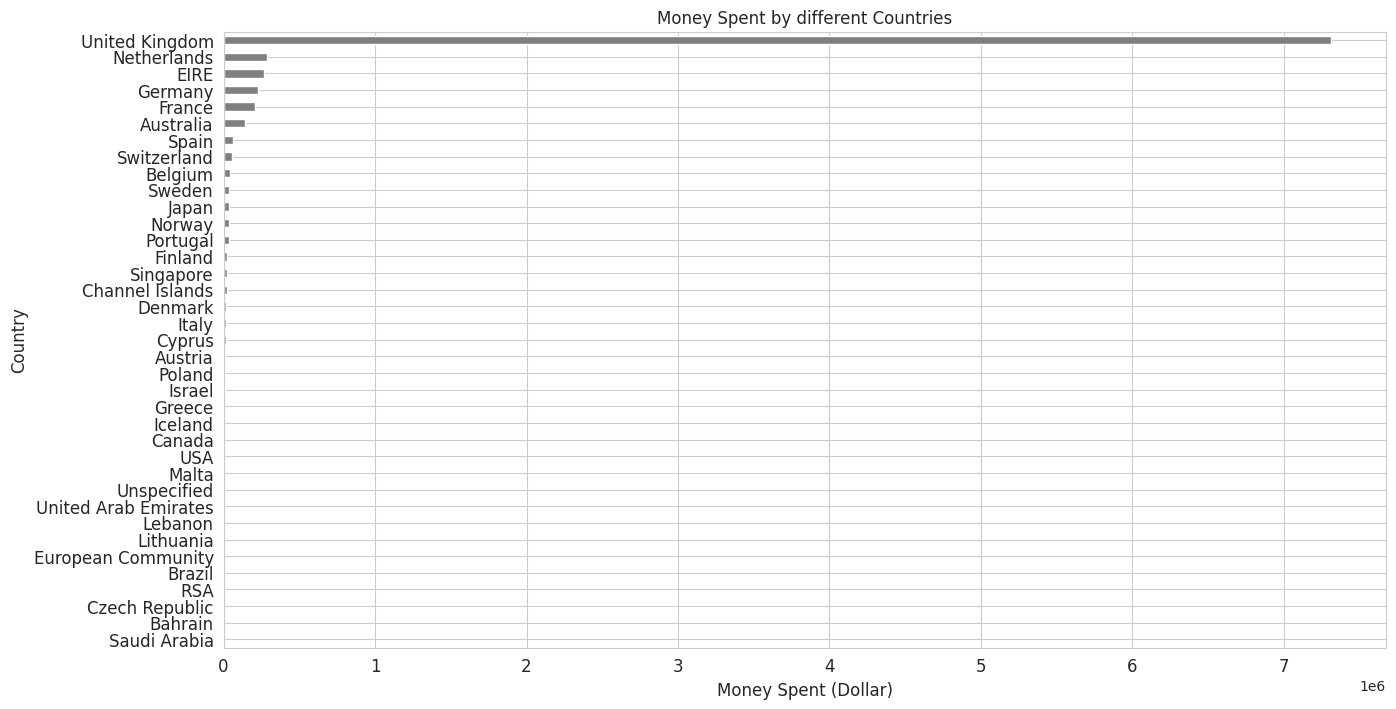

In [57]:
group_country_amount_spent = df2.groupby('country')['amount_spent'].sum().sort_values()
# del group_country_orders['United Kingdom']

# plot total money spent by each country (with UK)
plt.subplots(figsize=(15,8))
group_country_amount_spent.plot(kind='barh', fontsize=12, color=color[7])
plt.xlabel('Money Spent (Dollar)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Money Spent by different Countries', fontsize=12)
plt.show()

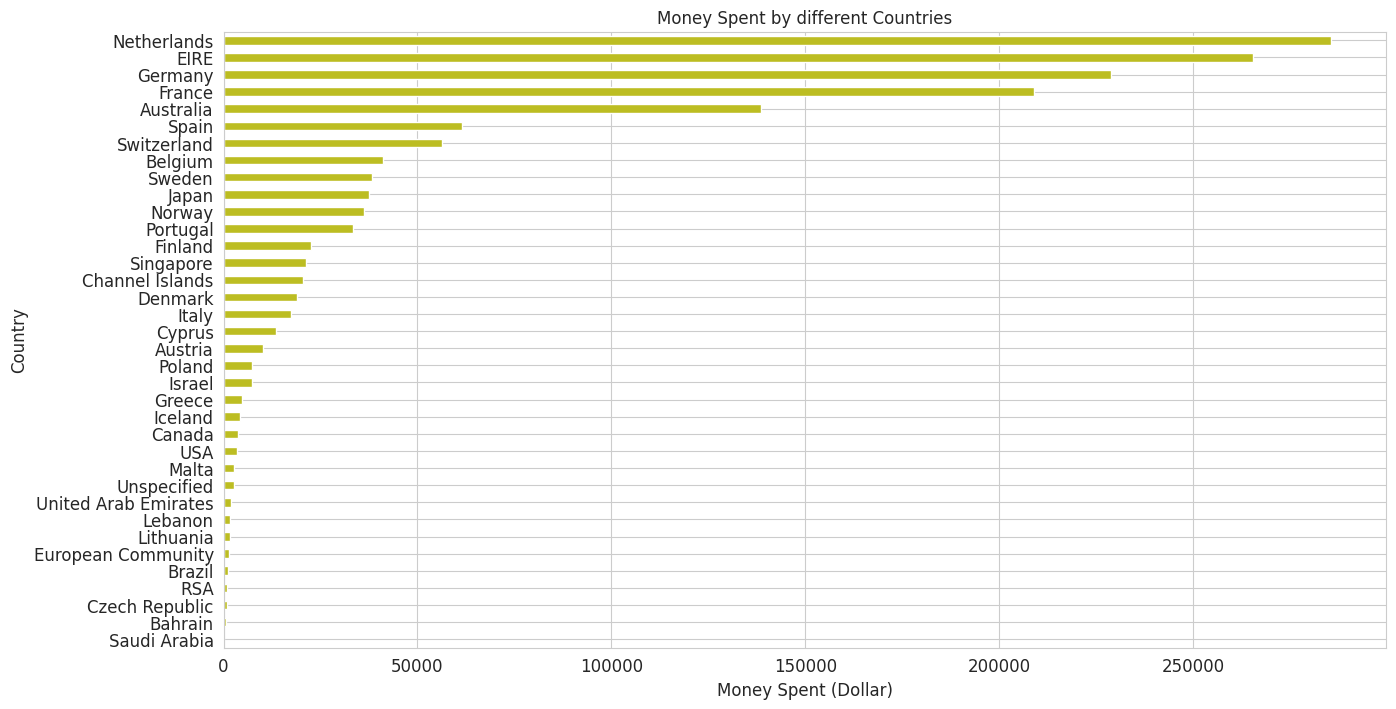

In [58]:
group_country_amount_spent = df2.groupby('country')['amount_spent'].sum().sort_values()
del group_country_amount_spent['United Kingdom']

# plot total money spent by each country (without UK)
plt.subplots(figsize=(15,8))
group_country_amount_spent.plot(kind='barh', fontsize=12, color=color[8])
plt.xlabel('Money Spent (Dollar)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Money Spent by different Countries', fontsize=12)
plt.show()

#ChronoTantra | ChronoYantra | ChronoMantra | ChronoSutra
 [Finished scrolling? Now try reading a book. ](http://chronos.yantrajaal.com) <br>

[![More Information](https://raw.githubusercontent.com/prithwis/parashar21/refs/heads/main/images/CTYMS-Colab-Footer.png)](https://chronos.yantrajaal.com)